# Configurações iniciais e pacotes importados

In [3]:
import numba
from numba import njit
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm, rayleigh

# Configuracao das figuras
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.linewidth"] = 1.2

# Para criar ama representação do caixa (onde seram introduzidas as partículas)
from matplotlib import animation
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [4]:
params = {
    "N": 200,
    "L": 10.0,
    "R": 0.1,
    "v0": 1.0,
    "m": 1.0,                       
    "velocity_distribution": "uniform", 
    "dt": 0.001,
    "n_steps": 20000,
    "n_cells": 20
}

# Funções a serem utilizadas

In [12]:
# Inicializa as posições das partículas de forma aleatória, garantindo que elas não se sobreponham
# Considera N partículas de raio R dentro de uma caixa quadrada de lado L
def initialize_positions(N, L, R):
    pos = np.zeros((N, 2))
    for i in range(N):
        while True:
            candidate = np.random.uniform(R, L - R, size=2)
            if i == 0:
                # Para a primeira partícula, basta aceitar a posição candidata
                pos[i] = candidate
                break
            dist = np.linalg.norm(pos[:i] - candidate, axis=1)
            if np.all(dist > 2 * R):
                pos[i] = candidate
                break
    return pos

In [13]:
# Inicializa as velocidades das partículas de acordo com a distribuição especificada
# Existe a opção de distribuição de velocidades "maxwell", "uniform" ou "fixed"
# maxwell: velocidades seguem uma distribuição normal com média 0 e desvio padrão v0
# uniform: velocidades são uniformemente distribuídas entre -v0 e v0
# fixed: todas as partículas têm a mesma velocidade v0, mas direções aleatórias
def initialize_velocities(N, distribution="maxwell", v0=1.0):
    if distribution == "maxwell":
        vel = np.random.normal(0, v0, size=(N, 2))
    elif distribution == "uniform":
        vel = np.random.uniform(-v0, v0, size=(N, 2))
    elif distribution == "fixed":
        angles = np.random.uniform(0, 2 * np.pi, N)
        vel = v0 * np.column_stack((np.cos(angles), np.sin(angles)))
    else:
        raise ValueError("Distribuição de velocidades desconhecida")

    # Remove o movimento do centro de massa
    vel -= np.mean(vel, axis=0)  # remove drift
    vel[:, 0] -= np.mean(vel[:, 0])
    vel[:, 1] -= np.mean(vel[:, 1])
    return vel

In [14]:
# Verifica e resolve colisões com as paredes da caixa
# Em caso de colisão, a posição é corrigida para ficar dentro da caixa e a velocidade é invertida na direção da colisão
@njit
def wall_collisions_fast(pos, vel, L, R):
    """
    Verifica e resolve colisões com as fronteiras da caixa [0, L].
    """
    N = pos.shape[0]
    for i in range(N):
        for d in range(2): # x e y
            # Parede inferior/esquerda
            if pos[i, d] <= R and vel[i, d] < 0:
                pos[i, d] = R
                vel[i, d] *= -1
            # Parede superior/direita
            elif pos[i, d] >= L - R and vel[i, d] > 0:
                pos[i, d] = L - R
                vel[i, d] *= -1
    return pos, vel

In [15]:
# Constrói a lista de células para otimizar a busca por vizinhos
# A caixa é dividida em uma grade de células de tamanho cell_size, e cada partícula é atribuída 
# à célula correspondente com base em sua posição

@njit
def build_cell_list_fast(pos, L, cell_size, n_cells):
    # Initialize cells as a list of lists (Numba handles this efficiently)
    cells = [[int(x) for x in range(0)] for _ in range(n_cells * n_cells)]
    
    # Assign particles to cells
    for i in range(len(pos)):
        cx = int(pos[i, 0] // cell_size)
        cy = int(pos[i, 1] // cell_size)
        
        # Boundary safety
        # Garantir que os índices das células estejam dentro dos limites (0 a n_cells-1)
        cx = max(0, min(cx, n_cells - 1))
        cy = max(0, min(cy, n_cells - 1))
        
        # Map 2D grid to 1D index: index = cx * n_cells + cy
        cells[cx * n_cells + cy].append(i)
    return cells

In [16]:
@njit
def particle_collisions_optimized(pos, vel, R, L, n_cells):
    N = pos.shape[0]
    cell_size = L / n_cells
    
    # head: armazena o índice da última partícula na célula
    # next_p: armazena o índice da partícula anterior na corrente
    head = np.full((n_cells, n_cells), -1, dtype=np.int32)
    next_p = np.empty(N, dtype=np.int32)
    
    # Monta a lista de células de forma eficiente
    for i in range(N):
        cx = int(pos[i, 0] / cell_size)
        cy = int(pos[i, 1] / cell_size)
        cx = max(0, min(cx, n_cells - 1))
        cy = max(0, min(cy, n_cells - 1))
        
        next_p[i] = head[cx, cy]
        head[cx, cy] = i

    two_r_sq = (2 * R)**2

    for cx in range(n_cells):
        for cy in range(n_cells):
            # Verifica a célula e vizinhos (dx, dy de -1 a 1)
            for dx in range(-1, 2):
                for dy in range(-1, 2):
                    ncx, ncy = cx + dx, cy + dy
                    if 0 <= ncx < n_cells and 0 <= ncy < n_cells:
                        i = head[cx, cy]
                        while i != -1:
                            j = head[ncx, ncy]
                            while j != -1:
                                if i < j: # Evita auto-colisão e dupla contagem
                                    dist_sq = (pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2
                                    if dist_sq <= two_r_sq:
                                        vel[i], vel[j] = resolve_collision(pos[i], pos[j], vel[i], vel[j])
                                j = next_p[j]
                            i = next_p[i]
    return vel


@njit
def resolve_collision(pos_i, pos_j, vel_i, vel_j):
    rel_pos = pos_i - pos_j
    rel_vel = vel_i - vel_j
    dot_product = np.dot(rel_vel, rel_pos)
    
    # SÓ RESOLVE SE O PRODUTO ESCALAR FOR NEGATIVO
    # Isso significa que as partículas estão se movendo uma em direção à outra
    if dot_product < 0:
        dist_sq = np.dot(rel_pos, rel_pos)
        if dist_sq == 0: return vel_i, vel_j
        
        impulse = (dot_product / dist_sq) * rel_pos
        vel_i_new = vel_i - impulse
        vel_j_new = vel_j + impulse
        return vel_i_new, vel_j_new
    
    return vel_i, vel_j

In [17]:
def animate_simulation(params, interval=20, save=False, color='dodgerblue', interaction=True):
    # 1. Inicialização correta usando suas funções
    pos = initialize_positions(params["N"], params["L"], params["R"])
    vel = initialize_velocities(
        params["N"], 
        params["velocity_distribution"], 
        params["v0"]
    )

    L = params["L"]
    R = params["R"]
    n_cells = params.get("n_cells", 20)

    # 2. Configuração da Figura
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.add_patch(plt.Rectangle((0, 0), L, L, color='black', fill=False, lw=2))

    # 3. Criação dos Círculos (Patches para precisão visual)
    circles = [plt.Circle(pos[i], R, color=color, ec='black', lw=0.5) for i in range(params["N"])]
    for c in circles:
        ax.add_patch(c)

    # 4. Função de Atualização
    def update(frame):
        nonlocal pos, vel
        
        # 10 passos de física por frame para velocidade visual
        for _ in range(10):
            pos, vel = update_step(pos, vel, L, R, params["dt"], n_cells, interaction=interaction)
        
        for i in range(len(circles)):
            circles[i].center = pos[i]
        
        return circles

    anim = FuncAnimation(
        fig, update,
        frames=params["n_steps"] // 10,
        interval=interval,
        blit=True
    )

    if save:
        anim.save('simulacao.mp4', writer='ffmpeg', fps=30)
        return None
    else:
        plt.close()
        return HTML(anim.to_jshtml())

In [18]:
def run_simulation_recorded(params, interaction=True):
    N, L, R, m = params["N"], params["L"], params["R"], params["m"]
    dt, n_steps = params["dt"], params["n_steps"]
    n_cells = params.get("n_cells", 20)

    # Inicialização correta
    pos = initialize_positions(N, L, R)
    vel = initialize_velocities(N, params["velocity_distribution"], params["v0"])

    pos_traj = np.zeros((n_steps, N, 2))
    vel_traj = np.zeros((n_steps, N, 2))
    e_kin = np.zeros(n_steps)

    for i in range(n_steps):
        # Passo de física com controle de interação
        pos, vel = update_step(pos, vel, L, R, dt, n_cells, interaction=interaction)
        
        pos_traj[i] = pos
        vel_traj[i] = vel
        e_kin[i] = 0.5 * m * np.sum(vel**2)
        
    return pos_traj, vel_traj, e_kin

# Dinâmica: Adicionando tempo à simulação

In [21]:
def update_step(pos, vel, L, R, dt, n_cells, interaction=True):
    # 1. Mover partículas (Integrador simples)
    pos += vel * dt
    
    # 2. Colisões com paredes (Sempre ativo)
    pos, vel = wall_collisions_fast(pos, vel, L, R)
    
    # 3. Colisões entre partículas (Opcional)
    if interaction:
        vel = particle_collisions_optimized(pos, vel, R, L, n_cells)
    
    return pos, vel

In [22]:
def run_simulation(p, interaction=True):
    # 1. USANDO SEUS INICIALIZADORES (Garante que posições sejam válidas)
    pos = initialize_positions(p["N"], p["L"], p["R"])
    vel = initialize_velocities(p["N"], p["velocity_distribution"], p["v0"])
    
    all_vels = []
    
    # 2. LOOP DE SIMULAÇÃO
    for i in range(p["n_steps"]):
        # Passa a flag 'interaction' para o update_step
        pos, vel = update_step(pos, vel, p["L"], p["R"], p["dt"], p["n_cells"], interaction=interaction)
        
        # 3. COLETA DE DADOS (Velocidades para histogramas)
        if i % 10 == 0: 
            all_vels.append(vel.copy())
            
    return np.array(all_vels)

# Testes

Testes para melhor compreensão e debug do código.

In [14]:
# anim = animate_simulation(params, 20, save=True)

# Resultados - Funções para obter observáveis físicos

In [23]:
def total_momentum(vel):
    """
    Retorna o módulo do momento total
    """
    P = np.sum(vel, axis=0)
    return np.linalg.norm(P)


def total_kinetic_energy(vel):
    """
    Energia cinética total
    """
    return 0.5 * np.sum(np.sum(vel**2, axis=1))

In [24]:
def run_simulation_observables(params):
    pos = initialize_positions(params["N"], params["L"], params["R"])
    vel = initialize_velocities(
        params["N"],
        params["velocity_distribution"],
        params["v0"]
    )

    P_hist = []
    E_hist = []

    for _ in range(params["n_steps"]):
        pos, vel = step(pos, vel, params)
        P_hist.append(total_momentum(vel))
        E_hist.append(total_kinetic_energy(vel))

    return np.array(P_hist), np.array(E_hist)

In [25]:
def plot_observables(P_hist, E_hist, dt):
    t = np.arange(len(P_hist)) * dt

    fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    ax[0].plot(t, P_hist)
    ax[0].set_ylabel(r"$|\mathbf{P}|$")
    ax[0].set_title("Momento total")

    ax[1].plot(t, E_hist)
    ax[1].set_ylabel(r"$E_{\mathrm{kin}}$")
    ax[1].set_xlabel("Tempo")

    plt.tight_layout()
    plt.show()

In [26]:
def animate_recorded_histogram(vel_traj, params, mode="speed", bins=40, interval=40, save=False):
    """
    Anima o histograma de velocidades usando Matplotlib a partir de dados gravados.
    """
    v0 = params["v0"]
    vlim = (0.0, 4 * v0) if mode == "speed" else (-4 * v0, 4 * v0)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Primeiro frame para inicializar os patches
    if mode == "speed":
        initial_data = np.sqrt(vel_traj[0, :, 0]**2 + vel_traj[0, :, 1]**2)
    else:
        initial_data = vel_traj[0, :, 0] if mode == "vx" else vel_traj[0, :, 1]
        
    n, bins_edges, patches = ax.hist(
        initial_data, bins=bins, range=vlim, 
        density=True, color='dodgerblue', alpha=0.7, edgecolor='white'
    )

    ax.set_xlim(*vlim)
    ax.set_ylim(0, 0.7) 
    ax.set_title(f"Evolução da Distribuição de Velocidades ({mode})")
    ax.set_ylabel("Densidade de Probabilidade")
    ax.set_xlabel(r"$|v|$" if mode == "speed" else r"$v_" + mode[-1] + "$")

    def update(frame):
        frame_idx = frame * 20
        if frame_idx >= len(vel_traj):
            return patches
            
        vel_now = vel_traj[frame_idx]
        
        if mode == "speed":
            data = np.sqrt(vel_now[:, 0]**2 + vel_now[:, 1]**2)
        else:
            data = vel_now[:, 0] if mode == "vx" else vel_now[:, 1]
            
        new_n, _ = np.histogram(data, bins=bins_edges, range=vlim, density=True)
        
        for rect, h in zip(patches, new_n):
            rect.set_height(h)
            
        return patches

    anim = FuncAnimation(
        fig, 
        update, 
        frames=len(vel_traj) // 20, 
        interval=interval, 
        blit=True
    )

    if save:
        plt.close()
        return anim  # Retorna o objeto FuncAnimation para permitir o uso de .save()
    else:
        plt.close()
        return HTML(anim.to_jshtml()) # Retorna o HTML para visualização direta

In [27]:
def analyze_observables(params, n_avg_steps=5000, interaction=True):
    """
    Realiza a simulação, extrai dados de equilíbrio e faz o ajuste (fit) 
    estatístico das distribuições de velocidade.
    """
    # 1. Rodar simulação e obter trajetórias
    # Usamos a versão gravada para ter uma amostragem estatística melhor
    _, v_traj, _ = run_simulation_recorded(params, interaction=interaction)
    
    # Pegar os últimos passos (onde o sistema já deve estar em equilíbrio)
    v_sample = v_traj[-n_avg_steps:]
    vx = v_sample[:, :, 0].flatten()
    vy = v_sample[:, :, 1].flatten()
    speed = np.sqrt(vx**2 + vy**2)

    # ==========================================
    # 2. AJUSTE (FIT) E NORMALIZAÇÃO
    # ==========================================
    
    # Ajuste para as componentes (Gaussiana/Normal)
    # Retorna média (loc) e desvio padrão (scale)
    mu_x, std_x = norm.fit(vx)
    mu_y, std_y = norm.fit(vy)
    
    # Ajuste para a velocidade escalar (Rayleigh / Maxwell 2D)
    # A Rayleigh no scipy é f(x) = (x/s^2) * exp(-x^2 / (2s^2))
    loc_s, scale_s = rayleigh.fit(speed)

    # ==========================================
    # 3. VISUALIZAÇÃO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Velocidade Escalar (Speed) ---
    ax1 = axes[0]
    # density=True garante que a área do histograma seja 1
    ax1.hist(speed, bins=50, density=True, alpha=0.6, color='skyblue', label='Dados Simulação')
    
    v_range = np.linspace(0, speed.max(), 200)
    pdf_rayleigh = rayleigh.pdf(v_range, loc_s, scale_s)
    ax1.plot(v_range, pdf_rayleigh, 'r-', lw=2.5, 
             label=f'Fit Maxwell-Boltzmann\n(Rayleigh, $\sigma$={scale_s:.3f})')
    
    ax1.set_title("Distribuição de Velocidade Escalar ($|v|$)")
    ax1.set_xlabel("Velocidade")
    ax1.set_ylabel("Densidade de Probabilidade")
    ax1.legend()

    # --- Plot 2: Componentes (vx e vy) ---
    ax2 = axes[1]
    ax2.hist(vx, bins=50, density=True, alpha=0.4, color='blue', label='$v_x$')
    ax2.hist(vy, bins=50, density=True, alpha=0.4, color='green', label='$v_y$')
    
    v_comp_range = np.linspace(vx.min(), vx.max(), 200)
    pdf_gauss = norm.pdf(v_comp_range, mu_x, std_x)
    ax2.plot(v_comp_range, pdf_gauss, 'k--', lw=2, 
             label=f'Fit Gaussiano\n($\mu$={mu_x:.2e}, $\sigma$={std_x:.3f})')
    
    ax2.set_title("Distribuição das Componentes ($v_x, v_y$)")
    ax2.set_xlabel("Velocidade da Componente")
    ax2.set_ylabel("Densidade de Probabilidade")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    
    return {"vx_std": std_x, "speed_scale": scale_s}

# Histogramas

In [ ]:
# 1. Configuração de parâmetros para um teste rápido e estatisticamente relevante
params_teste = {
    "N": 150,               # Quantidade suficiente para estatística, mas leve para o PC
    "L": 1.0,               # Tamanho da caixa
    "R": 0.01,              # Raio das partículas
    "v0": 1.0,              # Magnitude da velocidade inicial
    "m": 1.0,               # Massa
    "dt": 0.001,            # Passo de tempo estável
    "n_steps": 1000000,       # Tempo suficiente para ocorrerem milhares de colisões
    "n_cells": 15,          # Otimização de busca
    "velocity_distribution": "fixed" # Forçamos um estado inicial fora do equilíbrio
}

# 1. Rodar a simulação completa
pos_traj, vel_traj, e_kin = run_simulation_recorded(params, interaction=True)

# 2. Pegar apenas os primeiros 2000 passos (por exemplo) para ver o início
# Isso resolve o problema de "Animation size has reached..."
vel_traj_inicial = vel_traj[:100000] 

# 3. Chamar a função com save=True para obter o objeto anim
anim_to_save = animate_recorded_histogram(vel_traj_inicial, params, mode="speed", save=True)

# 4. Agora o .save() vai funcionar
anim_to_save.save('histograma_inicial.mp4', writer='ffmpeg', fps=30)

Rodando simulação com colisões (Gás Real)...


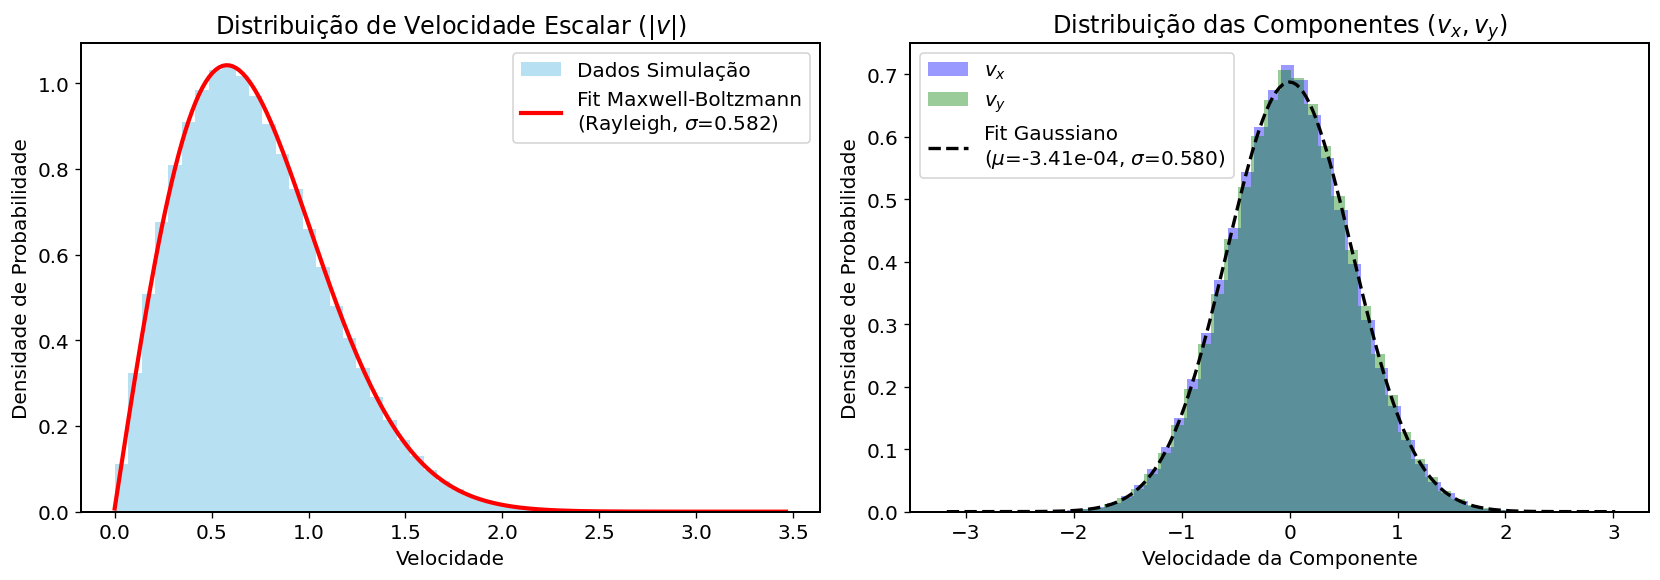

Rodando simulação sem colisões (Gás Ideal)...


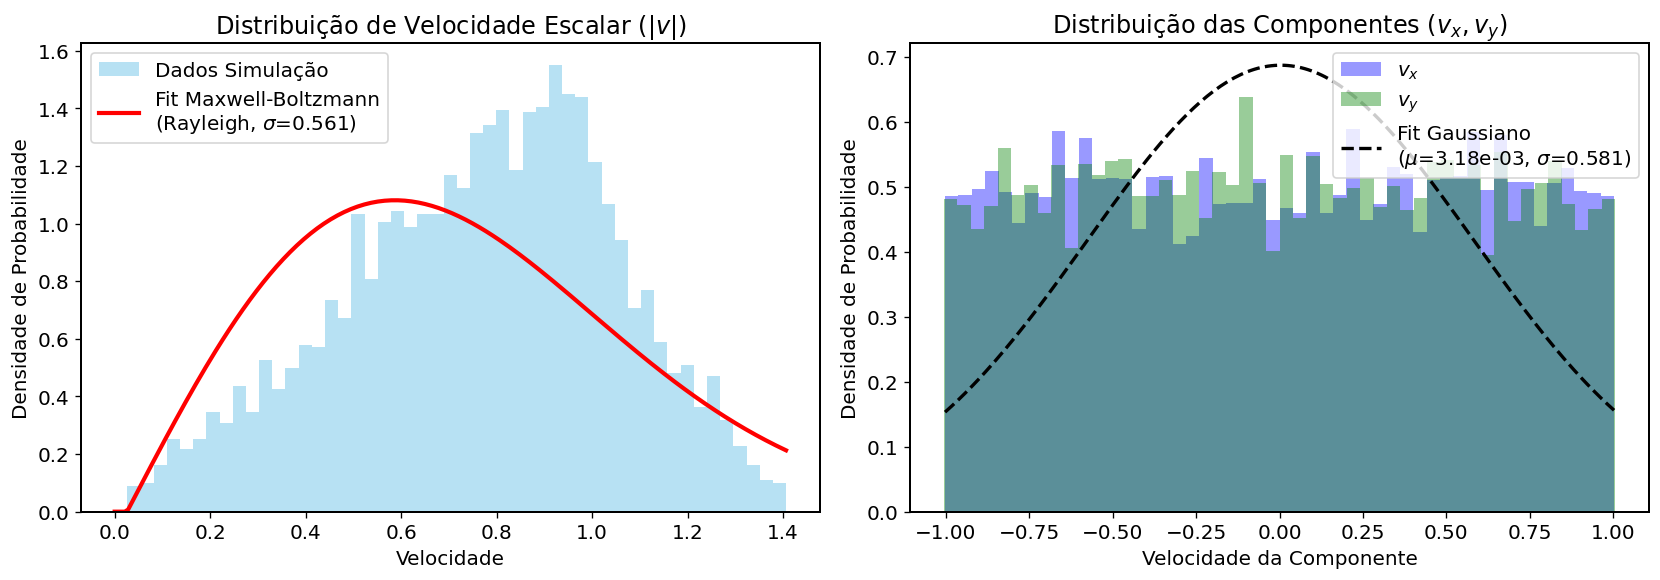

{'vx_std': np.float64(0.5806448199003151),
 'speed_scale': np.float64(0.5610900508813506)}

In [30]:
# 1. Configuração de parâmetros para um teste rápido e estatisticamente relevante
params_teste = {
    "N": 4000,               # Quantidade suficiente para estatística, mas leve para o PC
    "L": 20.0,               # Tamanho da caixa
    "R": 0.1,              # Raio das partículas
    "v0": 1.0,              # Magnitude da velocidade inicial
    "m": 1.0,               # Massa
    "dt": 0.01,            # Passo de tempo estável
    "n_steps": 20000,       # Tempo suficiente para ocorrerem milhares de colisões
    "n_cells": 200,          # Otimização de busca
    "velocity_distribution": "uniform" # Forçamos um estado inicial fora do equilíbrio
}

# 2. Execução da Análise com Interações (Gás Real)
# Queremos ver se as colisões levam o sistema ao equilíbrio (Maxwell-Boltzmann)
print("Rodando simulação com colisões (Gás Real)...")
analyze_observables(params_teste, n_avg_steps=8000, interaction=True)

# 3. Execução da Análise sem Interações (Gás Ideal)
# Aqui o sistema DEVE falhar em atingir a Maxwell-Boltzmann, 
# mantendo a distribuição original 'fixed' ou 'uniform'.
print("Rodando simulação sem colisões (Gás Ideal)...")
analyze_observables(params_teste, n_avg_steps=8000, interaction=False)